<a href="https://colab.research.google.com/github/averkina/Test2/blob/main/Test2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---Тестирование на примере №1----
Входные данные: 
[(0.7621083180927701, -0.14055282440529338), (0.11712191696366236, 0.24064185122105997), (0.19210823899069684, -0.4415048868269591), (0.1638517587277829, 0.8691878070815509)]
Выходные данные: (0.1781813956162305, 0.20455504638563787)


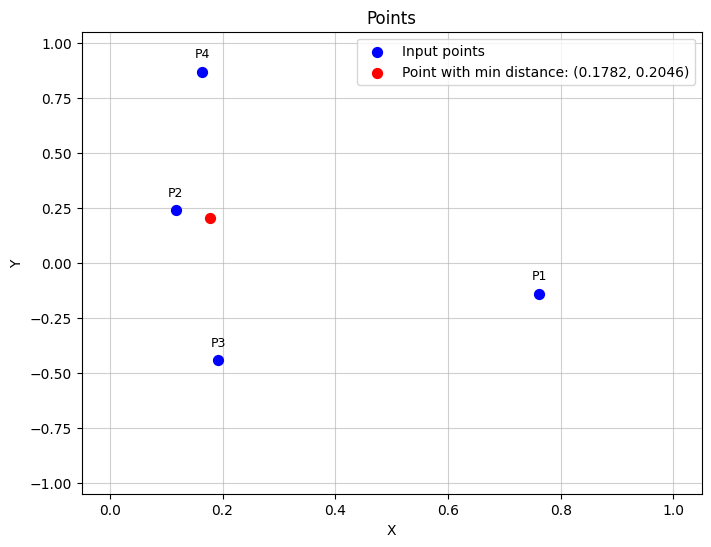

---Тестирование на примере №2----
Входные данные: 
[(0.7470239674262175, 0.6447069206938105), (0.20195105836405658, 0.20391396246608506), (0.5640664552576609, -0.4679579393136759), (0.965287093651108, 0.12111220555605673), (0.8989529115722917, -0.0013682274567241581), (0.8820818525597192, -0.3810653333566887), (0.5940319732405018, 0.23177586810615147), (0.47144169183066065, -0.5086735374243709)]
Выходные данные: (0.7356154087719764, -0.0073244988650146186)


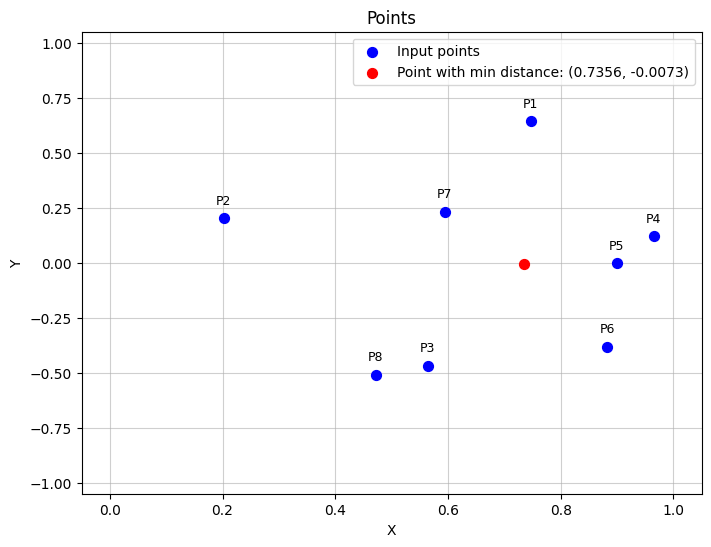

---Тестирование на примере пользователя----
Введите точки:
Количество точек (2-8): 0.4727755 0.824757 0.32874 0.32777428 0.3274829 0.4827584
Ошибка: введите число
Количество точек (2-8): 0,4275749 0,593489 0, 583575859 0,472879
Ошибка: введите число
Количество точек (2-8): 4
Точка 1 (x y): 0.883829 0.42883 0.83298748 0.284738
Ошибка: введите два числа через пробел
Точка 1 (x y): 0.843394 0.4872933
Точка 2 (x y): 0.943082392 0.4998023
Точка 3 (x y): 0.84782 0.248023
Точка 4 (x y): 0.4938922 0.42890
Входные данные: 
[(0.843394, 0.4872933), (0.943082392, 0.4998023), (0.84782, 0.248023), (0.4938922, 0.4289)]
Выходные данные: (0.8434534040803603, 0.48407752567032203)


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

#----Евклидово расстояние----
def distance(point, points):
    return np.sum(np.sqrt(np.sum((points - point) ** 2, axis=1)))#c помощью axis = 1 сразу для всех точек рассчитываю сумму квадратов по горизонтали, чтобы без цикла выполнять

#----нахождение целевой точки----
def find_min_dist_point(points):
    points = np.array(points)
    BOUNDS = [(0, 1), (-1, 1)]
    initial_point = np.mean(points, axis=0)# с помощью axis=0 считаю среднее по столбцам по x, y
    result = minimize(distance, initial_point, args=(points,), bounds=BOUNDS, method='L-BFGS-B')
    return result.x

#----график----
def plot(points, point):
    points = np.array(points)
    plt.figure(figsize=(8, 6))

    plt.scatter(points[:, 0], points[:, 1], color='blue', s=50, zorder=3, label='Input points')
    for i, (x, y) in enumerate(points):
        plt.annotate(f"P{i + 1}", (x, y), textcoords="offset points", xytext=(0, 10), ha='center', fontsize=9)
    plt.scatter(point[0], point[1], color='red', s=50, zorder=4, label=f'Point with min distance: ({point[0]:.4f}, {point[1]:.4f})')

    plt.xlim(-0.05, 1.05)
    plt.ylim(-1.05, 1.05)
    plt.xlabel('X')
    plt.ylabel('Y')

    plt.title('Points', fontsize=12)
    plt.grid(True, alpha=0.6)
    plt.legend(loc='upper right')
    plt.show()
#---функция для проверки точек которые вводит пользователь
def get_user_points():
    print("Введите точки:")

    while True:
        try:
            n = int(input("Количество точек (2-8): "))
            if 2 <= n <= 8:
                break
            print("Ошибка: требуется от 2 до 8")
        except ValueError:
            print("Ошибка: введите число")

    points = []
    i = 1
    while len(points) < n:
        try:
            x, y = map(float, input(f"Точка {i} (x y): ").split())
            if 0 <= x <= 1 and -1 <= y <= 1:
                points.append((x, y))
                i += 1
            else:
                print(f"Ошибка: X∈[0,1], Y∈[-1,1], а Вы ввели X={x}, Y={y}")
        except:
            print("Ошибка: введите два числа через пробел")

    return points

print("---Тестирование на примере №1----")
input_points = [
    (0.7621083180927701, -0.14055282440529338),
    (0.11712191696366236, 0.24064185122105997),
    (0.19210823899069684, -0.4415048868269591),
    (0.1638517587277829, 0.8691878070815509)
]
print("Входные данные: ")
print(input_points)

x, y = find_min_dist_point(input_points)
print(f"Выходные данные: ({x}, {y})")

#----График
plot(input_points, (x, y))


print("---Тестирование на примере №2----")
input_points = [
    (0.7470239674262175, 0.6447069206938105),
    (0.20195105836405658, 0.20391396246608506),
    (0.5640664552576609, -0.4679579393136759),
    (0.965287093651108, 0.12111220555605673),
    (0.8989529115722917, -0.0013682274567241581),
    (0.8820818525597192, -0.3810653333566887),
    (0.5940319732405018, 0.23177586810615147),
    (0.47144169183066065, -0.5086735374243709)
]
print("Входные данные: ")
print(input_points)

x, y = find_min_dist_point(input_points)
print(f"Выходные данные: ({x}, {y})")

#----График
plot(input_points, (x, y))

print("---Тестирование на примере пользователя----")
input_points = get_user_points()
print("Входные данные: ")
print(input_points)

x, y = find_min_dist_point(input_points)
print(f"Выходные данные: ({x}, {y})")

#----График
plot(input_points, (x, y))